# Caderno base: análise de séries temporais

Este caderno usa o exemplo didático dos slides da aula 14: **empréstimos da biblioteca por semana**. A ideia não é construir um modelo sofisticado, e sim praticar o fluxo básico de uma série temporal: organizar datas, visualizar tendência, suavizar ruído, decompor componentes e fazer um forecast simples.


## Pergunta de análise

Queremos responder: **semanas de prova aumentam o uso da biblioteca? Recessos e feriados reduzem?**

Em séries temporais, a ordem das observações faz parte do dado. Por isso, não tratamos as linhas como registros independentes e não embaralhamos treino e teste quando o objetivo é previsão.


In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from statsmodels.tsa.seasonal import seasonal_decompose

plt.style.use("default")
plt.rcParams.update({
    "figure.figsize": (11, 4.8),
    "axes.grid": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


## Dados de exemplo

Os slides mostram uma série semanal de empréstimos. Aqui vamos recriar essa série diretamente no caderno para manter o exercício autocontido. A coluna `semana` representa o fim da semana de agregação e `emprestimos` é a quantidade observada.


In [2]:
emprestimos_semanais = [
    42, 44, 47, 51, 55, 61, 66, 72,
    79, 86, 90, 95, 88, 74, 60, 41,
    35, 52, 68, 84, 91, 77,
]

serie = pd.Series(
    emprestimos_semanais,
    index=pd.date_range("2026-01-05", periods=len(emprestimos_semanais), freq="W-MON"),
    name="emprestimos",
)

df = serie.reset_index().rename(columns={"index": "semana"})
display(df.head())
display(df.tail())
print(f"Período: {serie.index.min().date()} a {serie.index.max().date()}")
print(f"Total de semanas: {len(serie)}")


,semana,emprestimos
0,2026-01-05,42
1,2026-01-12,44
2,2026-01-19,47
3,2026-01-26,51
4,2026-02-02,55


,semana,emprestimos
17,2026-05-04,52
18,2026-05-11,68
19,2026-05-18,84
20,2026-05-25,91
21,2026-06-01,77


Período: 2026-01-05 a 2026-06-01
Total de semanas: 22


### Leitura inicial

A série começa em janeiro, cresce até março, cai no começo de abril e volta a subir em maio. Antes de calcular qualquer modelo, essa inspeção já sugere eventos possíveis: maior demanda perto de avaliações e redução em semanas de recesso ou feriados.


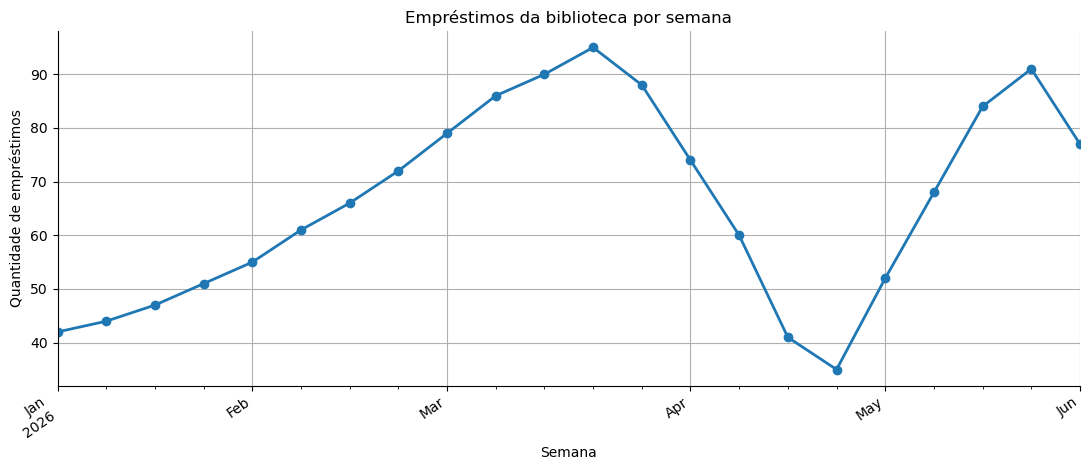

In [3]:
ax = serie.plot(marker="o", linewidth=2, color="#1f77b4")
ax.set_title("Empréstimos da biblioteca por semana")
ax.set_xlabel("Semana")
ax.set_ylabel("Quantidade de empréstimos")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


## Média móvel

A média móvel suaviza oscilações semanais e ajuda a enxergar a tendência. Nos slides, a média móvel de 4 semanas aparece como a linha de referência para comparar semanas acima ou abaixo do esperado.


In [4]:
media_movel = serie.rolling(window=4, min_periods=1).mean().rename("media_movel_4")
residuos = (serie - media_movel).rename("acima_ou_abaixo_da_media")

resumo = pd.concat([serie, media_movel, residuos], axis=1)
display(resumo.tail(8).round(1))


,emprestimos,media_movel_4,acima_ou_abaixo_da_media
2026-04-13,60,79.2,-19.2
2026-04-20,41,65.8,-24.8
2026-04-27,35,52.5,-17.5
2026-05-04,52,47.0,5.0
2026-05-11,68,49.0,19.0
2026-05-18,84,59.8,24.2
2026-05-25,91,73.8,17.2
2026-06-01,77,80.0,-3.0


### Interpretação da média móvel

A média móvel cai no fim de abril, porque as semanas anteriores foram fracas, e depois volta a subir em maio. Quando `acima_ou_abaixo_da_media` é positivo, a semana teve mais empréstimos que a referência recente; quando é negativo, ficou abaixo do padrão recente.


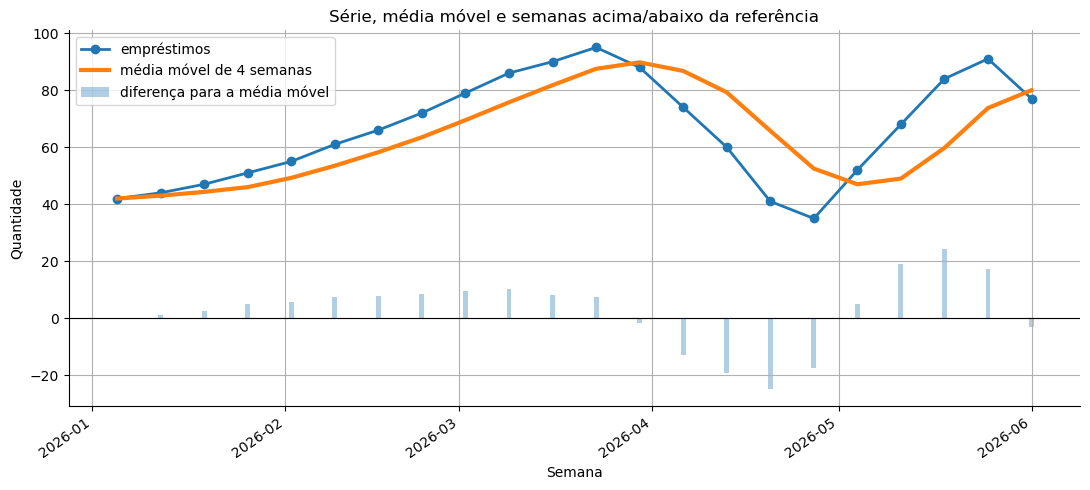

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(serie.index, serie.values, marker="o", linewidth=2, label="empréstimos")
ax.plot(media_movel.index, media_movel.values, linewidth=3, label="média móvel de 4 semanas")
ax.bar(residuos.index, residuos.values, alpha=0.35, label="diferença para a média móvel")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("Série, média móvel e semanas acima/abaixo da referência")
ax.set_xlabel("Semana")
ax.set_ylabel("Quantidade")
ax.legend()
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


## Decomposição sazonal

A decomposição separa a série em três partes: tendência, componente sazonal e resíduo. Como este é um exemplo curto e didático, vamos usar período 4 para representar um ciclo mensal aproximado em dados semanais.


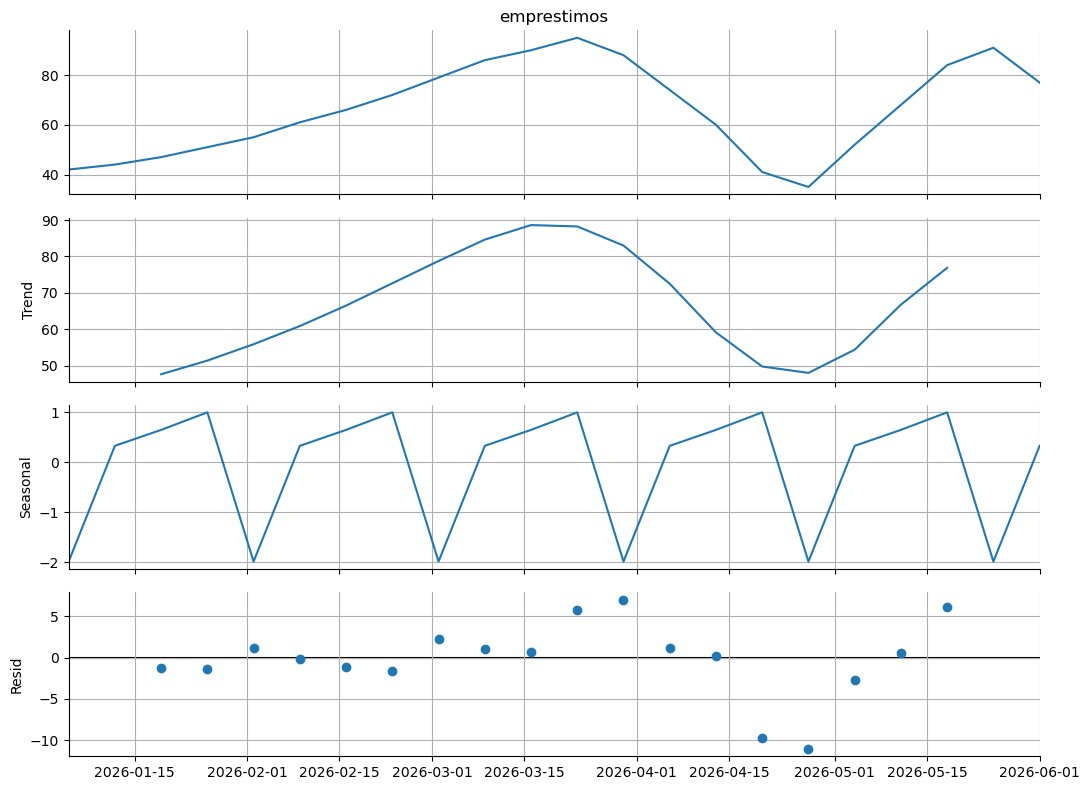

,observado,tendencia,sazonal,residuo
2026-04-13,60.0,59.1,0.6,0.2
2026-04-20,41.0,49.8,1.0,-9.8
2026-04-27,35.0,48.0,-2.0,-11.0
2026-05-04,52.0,54.4,0.3,-2.7
2026-05-11,68.0,66.8,0.6,0.6
2026-05-18,84.0,76.9,1.0,6.1
2026-05-25,91.0,NaN,-2.0,NaN
2026-06-01,77.0,NaN,0.3,NaN


In [6]:
decomp = seasonal_decompose(serie, model="additive", period=4)

fig = decomp.plot()
fig.set_size_inches(11, 8)
plt.tight_layout()
plt.show()

componentes = pd.DataFrame({
    "observado": decomp.observed,
    "tendencia": decomp.trend,
    "sazonal": decomp.seasonal,
    "residuo": decomp.resid,
})
display(componentes.tail(8).round(1))


### Interpretação da decomposição

A tendência resume o movimento de fundo: alta no primeiro bimestre, enfraquecimento em abril e recuperação em maio. O componente sazonal captura repetição de curto prazo, mas deve ser lido com cautela porque temos poucas semanas. O resíduo destaca semanas que fugiram do comportamento explicado pela tendência e pela sazonalidade.


## Separação temporal para previsão

Para avaliar previsão, a separação deve respeitar o tempo: usamos semanas antigas para estimar e semanas mais recentes para testar. Este exemplo usa um baseline simples: prever a próxima semana pela média das últimas 4 semanas observadas no treino.


In [7]:
treino = serie.iloc[:-4]
teste = serie.iloc[-4:]

previsao_teste = pd.Series(
    [treino.rolling(4).mean().iloc[-1]] * len(teste),
    index=teste.index,
    name="previsao_baseline",
)

avaliacao = pd.concat([teste.rename("real"), previsao_teste], axis=1)
avaliacao["erro"] = avaliacao["real"] - avaliacao["previsao_baseline"]
avaliacao["erro_absoluto"] = avaliacao["erro"].abs()
display(avaliacao.round(1))
print(f"MAE do baseline: {avaliacao['erro_absoluto'].mean():.1f} empréstimos")


,real,previsao_baseline,erro,erro_absoluto
2026-05-11,68,47.0,21.0,21.0
2026-05-18,84,47.0,37.0,37.0
2026-05-25,91,47.0,44.0,44.0
2026-06-01,77,47.0,30.0,30.0


MAE do baseline: 33.0 empréstimos


### Leitura da avaliação

O baseline é fácil de explicar, mas reage lentamente quando há retomada forte. Se o erro absoluto fica grande nas semanas de maio, isso indica que a média das semanas anteriores estava subestimando a recuperação da demanda.


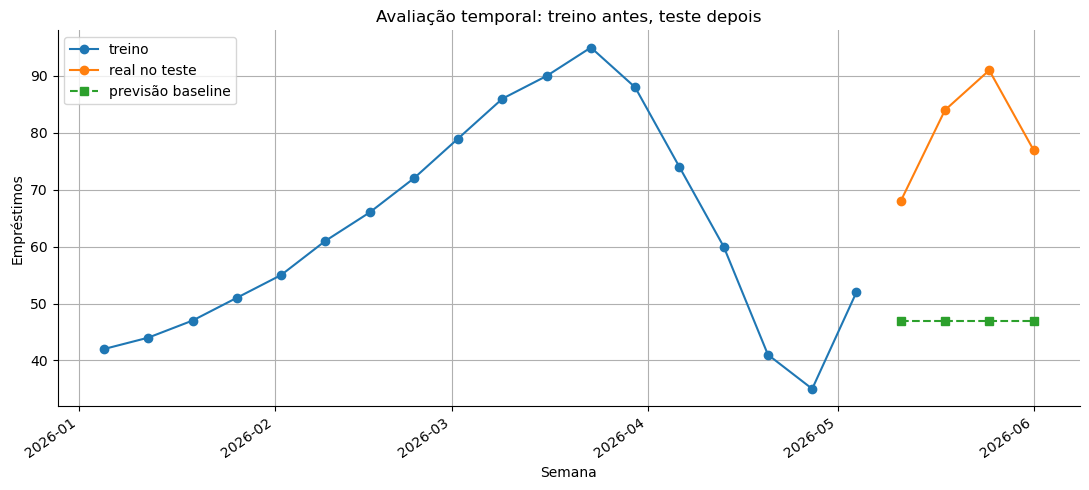

In [8]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(treino.index, treino.values, marker="o", label="treino")
ax.plot(teste.index, teste.values, marker="o", label="real no teste")
ax.plot(previsao_teste.index, previsao_teste.values, marker="s", linestyle="--", label="previsão baseline")
ax.set_title("Avaliação temporal: treino antes, teste depois")
ax.set_xlabel("Semana")
ax.set_ylabel("Empréstimos")
ax.legend()
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


## Forecast simples para as próximas semanas

Agora projetamos quatro semanas futuras usando a inclinação média das últimas quatro semanas. É uma regra simples, útil para discutir hipóteses, mas não substitui validação com histórico maior.


In [9]:
ultimas = serie.tail(4)
passo = (ultimas.iloc[-1] - ultimas.iloc[0]) / (len(ultimas) - 1)
semanas_futuras = pd.date_range(serie.index[-1] + pd.offsets.Week(weekday=0), periods=4, freq="W-MON")
forecast = pd.Series(
    [serie.iloc[-1] + passo * i for i in range(1, 5)],
    index=semanas_futuras,
    name="forecast_simples",
)

display(forecast.round(1).to_frame())
print(f"Inclinação média usada no forecast: {passo:.1f} empréstimos por semana")


,forecast_simples
2026-06-08,80.0
2026-06-15,83.0
2026-06-22,86.0
2026-06-29,89.0


Inclinação média usada no forecast: 3.0 empréstimos por semana


### Interpretação do forecast

A projeção herda a tendência recente. Como a última semana observada caiu de 91 para 77, a inclinação média das últimas quatro semanas ainda pode ser positiva, mas mais moderada do que o pico de maio. Em um relatório real, esta previsão deveria vir acompanhada das hipóteses: calendário acadêmico, avaliações, férias, acervo e mudanças de política de empréstimo.


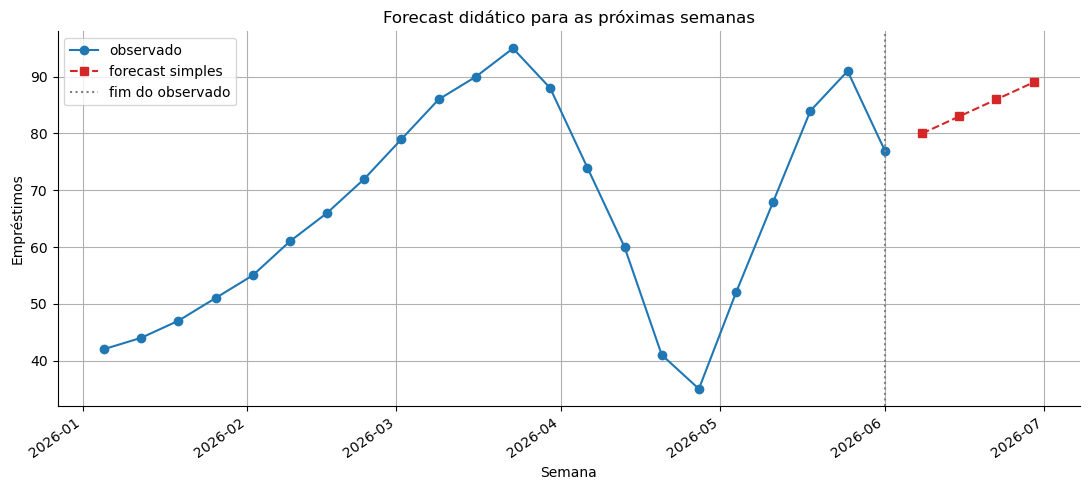

In [10]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(serie.index, serie.values, marker="o", label="observado")
ax.plot(forecast.index, forecast.values, marker="s", linestyle="--", color="#d62728", label="forecast simples")
ax.axvline(serie.index[-1], color="gray", linestyle=":", label="fim do observado")
ax.set_title("Forecast didático para as próximas semanas")
ax.set_xlabel("Semana")
ax.set_ylabel("Empréstimos")
ax.legend()
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


## Fechamento

Este caderno mostra o mínimo defensável para começar uma análise temporal: criar uma série indexada por data, visualizar, suavizar, decompor, separar treino/teste respeitando o tempo e comunicar limites. O próximo passo natural seria enriquecer os dados com calendário acadêmico, semanas de prova, feriados e recessos.
